## **Python Tutorial Assessment**
### BMI 500: Introduction to Ethical Data Science and Informatics

In [5]:
import pandas as pd
import numpy as np

#### Problem 1. Write a function in Python 3.x that, given an integer n, returns the sum of the first n terms of the series in the Leibniz formula.

In [2]:
def leibniz_sum(n):
    if n < 0:
        raise ValueError("n must be non-negative.")
    return sum((-1)**k / (2*k + 1) for k in range(n))

#### Problem 2. For each of the following items, write a function in Python 3.x that, given an integer n, returns the sum of the first n terms of the series in the Leibniz formula.

a. Use a for-loop and an if-statement with the modulo operator % to determine whether
to add or subtract each term.

In [11]:
def leibniz_2a(n):
    sum = 0
    for i in range(n):
        if i % 2 == 0:
            sum += 1 / (2 * i + 1)
        else:
            sum -= 1 / (2 * i + 1)
    return sum

b. Use a for-loop with the quantity (-1)**n to determine whether to add or subtract each term.

In [4]:
def leibniz_2b(n):
    sum = 0
    for i in range(n):
        sum += (-1)**i / (2 * i + 1)
    return sum

c. Construct a Python list and compute the sum of the terms in the list.

In [6]:
def leibniz_2c(n):
    terms = [] # initialize empty list
    
    for i in range(n):
        term = (-1)**i / (2 * i + 1)
        terms.append(term)
    return sum(terms)

d. Construct a Python set and compute the sum of the terms in the set.

In [7]:
def leibniz_2d(n):
    terms = set() # initialize empty set
    terms = {(-1)**i / (2 * i + 1) for i in range(n)} 
    return sum(terms)

e. Construct a Python dictionary and compute the sum of the terms in the dictionary.

In [8]:
def leibniz_2e(n):
    terms = {} # initialize empty dictionary
    terms = {i: (-1)**i / (2 * i + 1) for i in range(n)} 
    return sum(terms.values())

f. Construct a NumPy array and compute the sum of the terms in the array.

In [9]:
def leibniz_2f(n):
    terms = np.array([(-1)**i / (2 * i + 1) for i in range(n)])
    return np.sum(terms)

g. Construct a NumPy array, use array indexing to compute the sum of the positive terms in the array, use array indexing to compute the sum of the negative terms in the array, and add the two sums together. You can write x[::2] to access the first, third, etc. terms and x[1::2] to access the second, fourth, etc. terms.

In [15]:
def leibniz_2g(n):
    i = np.arange(n)
    
    positive = np.sum(((-1)**i / (2 * i + 1))[::2])   # First, third, etc.
    negative = np.sum(((-1)**i / (2 * i + 1))[1::2])  # Second, fourth, etc.
    
    return positive + negative

j. Combine the first and second terms, the third and fourth terms, etc. to change this series from an alternating to a non-alternating series and compute the sum of the combined terms.

In [13]:
def leibniz_2j(n):
    num_pairs = n // 2 # number of complete pairs
    total = 0
    
    for i in range(num_pairs):
        total += 2 / ((4 * i + 1) * (4 * i + 3))
    
    if n % 2 == 1: # if n is odd, include the last term
        total += 1 / (2*n - 1)
    
    return total

#### Problem 3. Which of these implementations of the Leibniz formula is the most accurate, fastest, and/or clearest? Which function would you use to calculate π (and why)? You can use the. built-in constants math.pi or np.pi for assessing the accuracy of your functions and the time package or the %timeit command for timing.

In [31]:
import math
import timeit

n = 500000
functions = [
    leibniz_2a, leibniz_2b, leibniz_2c, leibniz_2d,
    leibniz_2e, leibniz_2f, leibniz_2g, leibniz_2j
]

# Reference sum for the first n terms
reference = math.fsum((-1)**k / (2*k + 1) for k in range(n))

results = []

for function in functions:
    
    result = function(n)
    seconds = min(timeit.repeat(lambda: function(n), number=1, repeat=5))

    results.append({
        "Function": function.__name__,
        "Accurate": math.isclose(result, reference, rel_tol=1e-12, abs_tol=1e-12),
        "π estimate": 4 * result, # result returns π/4
        "Absolute π error": abs(4 * result - math.pi), # difference from pi
        "Time (seconds)": seconds
    })

pd.DataFrame(results).sort_values("Time (seconds)") # sort by ascending time

,Function,Accurate,π estimate,Absolute π error,Time (seconds)
6,leibniz_2g,True,3.141591,0.000002,0.017185
7,leibniz_2j,True,3.141591,0.000002,0.028268
0,leibniz_2a,True,3.141591,0.000002,0.044915
1,leibniz_2b,True,3.141591,0.000002,0.115122
2,leibniz_2c,True,3.141591,0.000002,0.124299
4,leibniz_2e,True,3.141591,0.000002,0.135377
5,leibniz_2f,True,3.141591,0.000002,0.135556
3,leibniz_2d,True,3.141591,0.000002,0.213253


Using 500,000 terms, all implementations accurately estimated π and had the same absolute error of 0.000002. The implementation used in 2g (Numpy array and sums the positive and negative terms after array indexing) is the fastest (0.0164 seconds), followed by 2j (changing series to non-alternating). 2d's approach (summing items in a set) is the slowest (0.1944 seconds). I would use the implementation in 2g to calculate π because it has the fastest speed while maintaining the accuracy. 

#### Problem 4. Choose your favorite implementation of this formula, and plot the absolute error in the sum as a function of the number of terms in the sum.

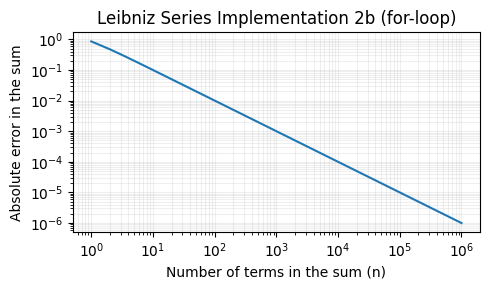

In [40]:
import matplotlib.pyplot as plt

# Various number of terms for plotting
term_counts = np.unique(np.logspace(0, 6, 50).astype(int))
errors = [abs(4 * leibniz_2b(n) - math.pi) for n in term_counts]

plt.figure(figsize=(5, 3))
plt.loglog(term_counts, errors)
plt.xlabel("Number of terms in the sum (n)")
plt.ylabel("Absolute error in the sum")
plt.title("Leibniz Series Implementation 2b (for-loop)")
plt.grid(True, which="both", alpha=0.2)
plt.tight_layout()
plt.show()

As the number of terms in the sum increases, the absolute error in the sum decreases linearly.

#### Problem 5. Would you do anything diﬀerently for computing π using the Leibniz formula if you were using MATLAB instead of Python?

In MATLAB, I would replace the Python for-loop implementation in 2b with vectorized array operations, which expresses the sum more concisely. This would require the element-wise operators `./` and `.^` instead of `/` and `^`. Additionally, because MATLAB array occupies a single contiguous block of memory and appending to it reallocates and copies the entire array on every iteration, growing an array costs O(n²) instead of O(n) used in Python list.append, I would consider preallocating the results array with zeros when implementing a loop. 